# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [102]:
# Import the library
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

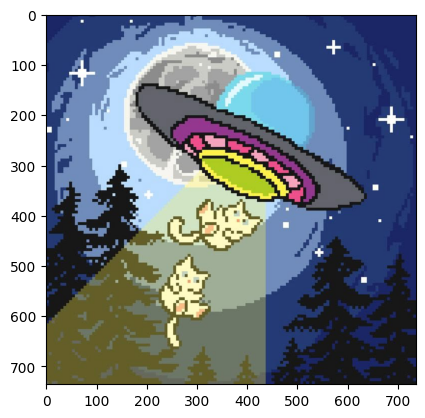

In [103]:
# ── Load image ────────────────────────────────────
meow = Image.open('meow.jpe') #load image into a PIL Image object
plt.imshow(meow, cmap = cm.Greys_r)
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [104]:
# Get the size of the image
print(meow.size)
w, h = meow.size
# scaling factors
X=2
Y=2

(736, 736)


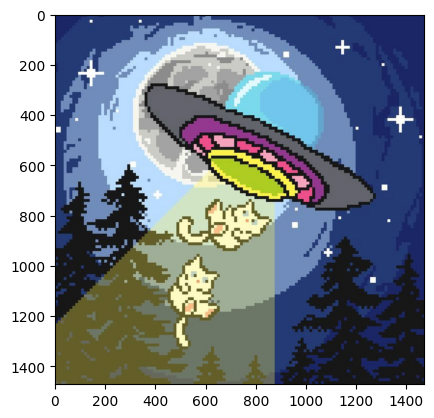

In [105]:
# ── 1. Increase size (scale ×2) ────────────────────
new_size=(X*w,Y*h)
# Resize the image using PIL's built-in method
meow2 = meow.resize(new_size, Image.Resampling.LANCZOS)
plt.imshow(meow2, cmap = cm.Greys_r)
plt.show()

(1472, 1472)


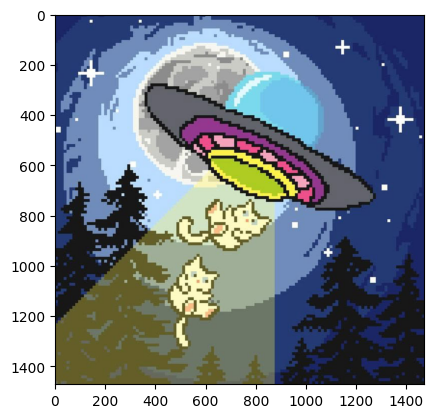

In [106]:
meow2.save('task1_1_scaled.jpg')
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
task1_1_scaled = Image.open('task1_1_scaled.jpg')
print(task1_1_scaled.size)
plt.imshow(task1_1_scaled, cmap = cm.Greys_r)
plt.show()

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [107]:
Y2=1

In [108]:
new_size2=(X*w,Y2*h)
# Resize the image using PIL's built-in method
meowH = meow.resize(new_size2, Image.Resampling.LANCZOS)
meowH.size

(1472, 736)

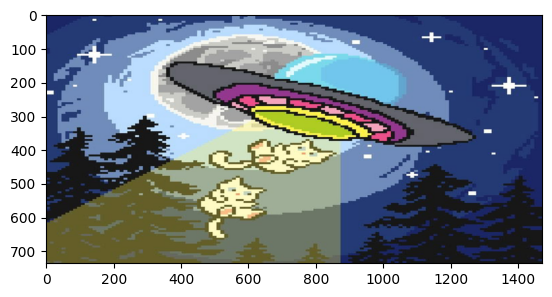

In [109]:
plt.imshow(meowH, cmap = cm.Greys_r)
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

(1006, 1006)


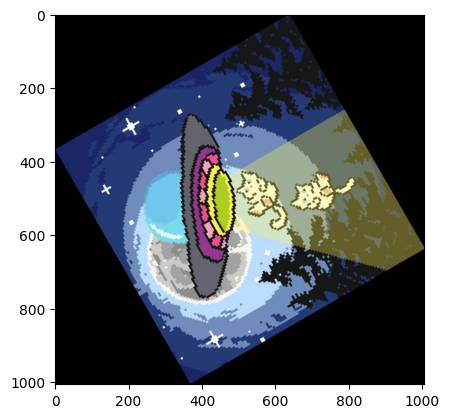

In [119]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated = meow.rotate(120, expand=True)
rotated.save("task1_2_rotated.jpg")
task1_2_rotated = Image.open('task1_2_rotated.jpg')
print(task1_2_rotated.size)
plt.imshow(task1_2_rotated, cmap = cm.Greys_r)
plt.show()

### 3. Shear

In [120]:
# -- c. Get the image dimensions ────────────────────
meow.size

(736, 736)

In [135]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0
shy = 0.7
tx = 0
ty = 0

In [136]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
matrix = (1, shx, tx,
          shy, 1, ty)
sheared = meow.transform(
    (w, h),
    Image.AFFINE,
    matrix,
    resample=Image.Resampling.BICUBIC
)

(736, 736)


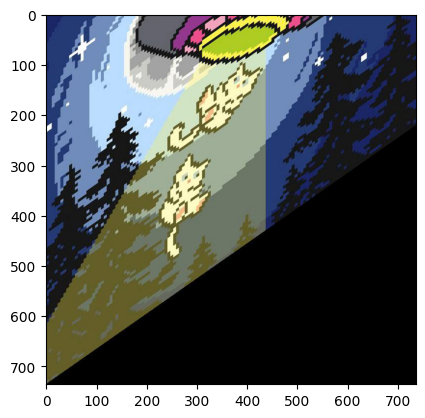

In [137]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared.save("task1_3_sheared.jpg")
task1_3_sheared = Image.open('task1_3_sheared.jpg')
print(task1_3_sheared.size)
plt.imshow(task1_3_sheared, cmap = cm.Greys_r)
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

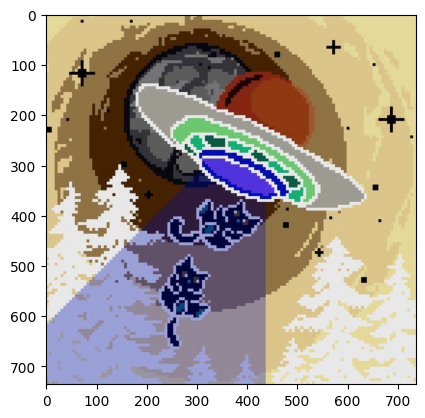

In [146]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
import numpy as np
arr = np.array(meow)

neg_arr = 255 - arr
neg_img = Image.fromarray(neg_arr)

neg_img.save("task_negative_numpy.jpg")
task_negative_numpy = Image.open('task_negative_numpy.jpg')
plt.imshow(task_negative_numpy, cmap = cm.Greys_r)
plt.show()

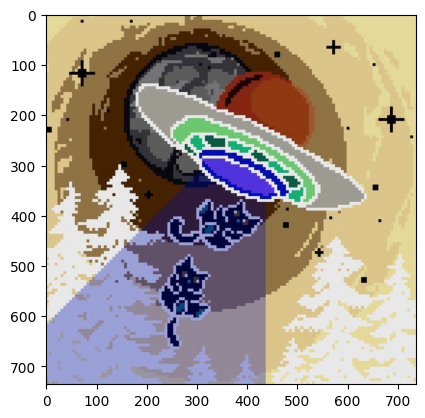

In [149]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

neg_img = ImageOps.invert(meow)

neg_img.save("task_negative_pil.jpg")
task_negative_pil = Image.open('task_negative_pil.jpg')
plt.imshow(task_negative_pil, cmap = cm.Greys_r)
plt.show()


C:\Users\shaha\AppData\Local\Temp\ipykernel_34420\1875553440.py:13: RuntimeWarning: divide by zero encountered in log
  log_arr = c * np.log(1 + arr)


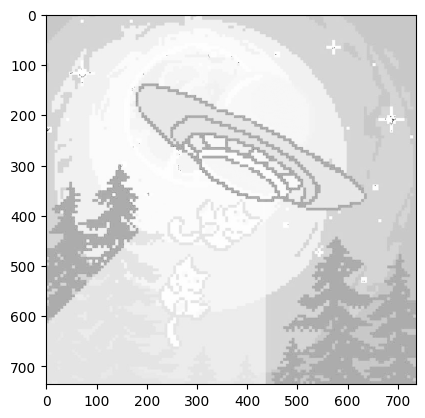

In [152]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
import math
img = meow.convert("L")
arr = np.array(img)
c = 255 / math.log(1 + 255)

# Apply the log transformation to each pixel
log_arr = c * np.log(1 + arr)
log_arr = np.clip(log_arr, 0, 255).astype(np.uint8)

log_img = Image.fromarray(log_arr)
log_img.save("task_log.jpg")
task_log = Image.open('task_log.jpg')
plt.imshow(task_log, cmap = cm.Greys_r)
plt.show()

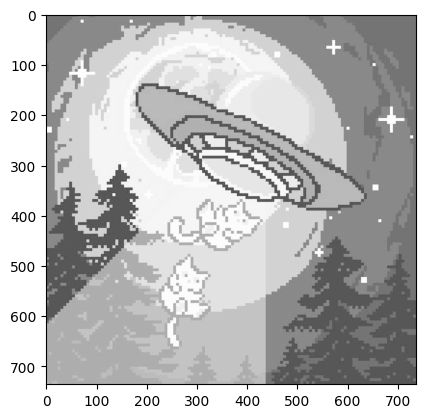

In [153]:

# ── 3. Power-law / Gamma correction ───────────────
arr = arr / 255.0   

gamma = 0.5  
c = 1

gamma_arr = c * (arr ** gamma)
gamma_arr = np.clip(gamma_arr * 255, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_arr)
gamma_img.save("task_gamma.jpg")
task_gamma = Image.open('task_gamma.jpg')
plt.imshow(task_gamma, cmap = cm.Greys_r)
plt.show()